# Etapa 4 — Modelado de P1 (predicción de entrega tardía)

**Vertex Insights — Proyecto Final · Sprint 1 · fase CRISP-DM: Modeling**

Objetivo: predecir en el momento de la compra (**t0**) si una orden de Olist llegará **tarde** respecto a la fecha prometida (`entrega_tarde`, clasificación binaria desbalanceada, tasa base 8.11%).

Este notebook **reutiliza** la librería reproducible `src/models` (baseline, entrenamiento y evaluación) sobre la tabla analítica y el preprocesador de la Etapa 3. No rehace features ni el split temporal; respeta la disciplina anti-leakage (solo features [t0], `fit` solo en train, selección por `val`, `test` reportado una vez).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent  # notebooks/ -> raíz del repo
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Image, display
from src.models.train import run, DEFAULT_DATA
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

## 1. Entrenamiento y evaluación completos

Se miden dos baselines (piso), se entrena una pequeña rejilla por familia (Regresión Logística y XGBoost) eligiendo el mejor candidato por **PR-AUC en validación**, se fija el umbral operativo, se audita la fuga (R-12) y se serializa el modelo elegido.

In [2]:
salida = run(DEFAULT_DATA)

[1/6] Cargando tabla analitica: C:\Users\Nassi\OneDrive\Desktop\vertex-olist\vertex-insights-olist-recommender\data\processed\orders_p1_features.csv


      filas: total=96,470 train=67,529 val=14,470 test=14,471
      tasa_base: total=0.0811 train=0.0903 val=0.0534 test=0.0661  (cae con el tiempo: R-14)
[2/6] Baselines (piso de comparacion) ...
      baseline_mayoritaria   PR-AUC(test)=0.0661
      baseline_regla         PR-AUC(test)=0.0523
[3/6] Entrenando clasificadores (rejilla; fit solo en train) ...


      logistic_regression  lr_C1.0      PR-AUC(val)=0.1504


      logistic_regression  lr_C0.3      PR-AUC(val)=0.1504
      -> logistic_regression: lr_C1.0 | PR-AUC(test)=0.1105 ROC-AUC(test)=0.6650 recall(test)=0.234


      xgboost              xgb_d4_l2    PR-AUC(val)=0.1655


      xgboost              xgb_d6_l5    PR-AUC(val)=0.1519
      -> xgboost: xgb_d4_l2 | PR-AUC(test)=0.1237 ROC-AUC(test)=0.7028 recall(test)=0.346
[4/6] Seleccion del candidato (PR-AUC en val) ...
      candidato: xgboost (xgb_d4_l2) | umbral F1=0.574
      punto alta cobertura (umbral=0.468): recall(test)=0.628 precision(test)=0.118
[5/6] Auditoria de fuga y analisis de errores (test) ...
      peso de `tasa_vendedor` en el modelo: 6.0%
      OK: metricas en rango realista, sin senal de fuga.
      tardanza/recall por region (test):
      region  n_ordenes  tasa_tarde_real  recall_tarde  n_tarde
     Sudeste      10228           0.0760        0.2999      777
    Nordeste       1256           0.0525        0.8333       66
Centro-Oeste        837           0.0490        0.5366       41
       Norte        225           0.0400        0.5556        9
         Sul       1925           0.0332        0.2500       64
      desempeno por historial de vendedor (test):
                  segmen

[6/6] Serializando modelo elegido y metricas ...
      modelo serializado en: C:\Users\Nassi\OneDrive\Desktop\vertex-olist\vertex-insights-olist-recommender\artifacts\modelo_p1.joblib
      metricas en: C:\Users\Nassi\OneDrive\Desktop\vertex-olist\vertex-insights-olist-recommender\reports\etapa4_metrics.json


## 2. Comparación de modelos (TEST)

Métrica principal: **PR-AUC** (informativa con clases desbalanceadas; el azar vale ~la tasa base 0.066). **ROC-AUC** mide discriminación global. **Brier** mide calibración (menor es mejor).

In [3]:
filas = []
for nombre, m in salida['metricas'].items():
    t = m['test']
    filas.append({'modelo': nombre, 'PR-AUC': t['pr_auc'], 'ROC-AUC': t['roc_auc'],
                  'recall': t['recall'], 'precision': t['precision'], 'Brier': t['brier']})
tabla = pd.DataFrame(filas).set_index('modelo')
tabla

,PR-AUC,ROC-AUC,recall,precision,Brier
modelo,,,,,
baseline_mayoritaria,0.0661,0.5000,1.0000,0.0661,0.0623
baseline_regla,0.0523,0.3402,0.1108,0.0524,0.3494
logistic_regression,0.1105,0.6650,0.2341,0.1044,0.2963
xgboost,0.1237,0.7028,0.3459,0.1323,0.1855


## 3. Punto de operación, auditoría de fuga y análisis de errores

El punto de **alta cobertura** sirve para alertar órdenes en riesgo (prioriza recall). La auditoría de fuga confirma que `tasa_vendedor` no domina y que las métricas son realistas (sin valores ~1.0).

In [4]:
print('Mejor modelo:', salida['mejor_modelo'], '(' + salida['config_mejor'] + ')')
print('Umbral F1:', round(salida['umbral_f1'], 3))
ac = salida['operativo_alta_cobertura']
print('Alta cobertura -> umbral', round(ac['umbral'], 3),
      '| recall', round(ac['recall'], 3), '| precision', round(ac['precision'], 3))
print('Peso de tasa_vendedor (fuga):', round(salida['peso_tasa_vendedor'] * 100, 1), '%')
print('\nTasa base por split:', salida['tasa_base_por_split'])

Mejor modelo: xgboost (xgb_d4_l2)
Umbral F1: 0.574
Alta cobertura -> umbral 0.468 | recall 0.628 | precision 0.118
Peso de tasa_vendedor (fuga): 6.0 %

Tasa base por split: {'train': 0.09027232744450532, 'val': 0.053420870767104355, 'test': 0.06613226452905811}


In [5]:
print('Desempeño por región (test):')
display(pd.DataFrame(salida['analisis_region']))
print('Desempeño por historial de vendedor (cold-start):')
display(pd.DataFrame(salida['analisis_cold_start']))

Desempeño por región (test):


,region,n_ordenes,tasa_tarde_real,recall_tarde,n_tarde
0,Sudeste,10228,0.0760,0.2999,777
1,Nordeste,1256,0.0525,0.8333,66
2,Centro-Oeste,837,0.0490,0.5366,41
3,Norte,225,0.0400,0.5556,9
4,Sul,1925,0.0332,0.2500,64


Desempeño por historial de vendedor (cold-start):


,segmento,n_ordenes,tasa_tarde_real,pr_auc,roc_auc,recall,precision
0,con historial,12820,0.0673,0.1260,0.7007,0.3511,0.1344
1,cold-start (sin historial),1651,0.0569,0.1062,0.7217,0.2979,0.1134


## 4. Figuras

Curvas PR/ROC, calibración, error por región e importancias.

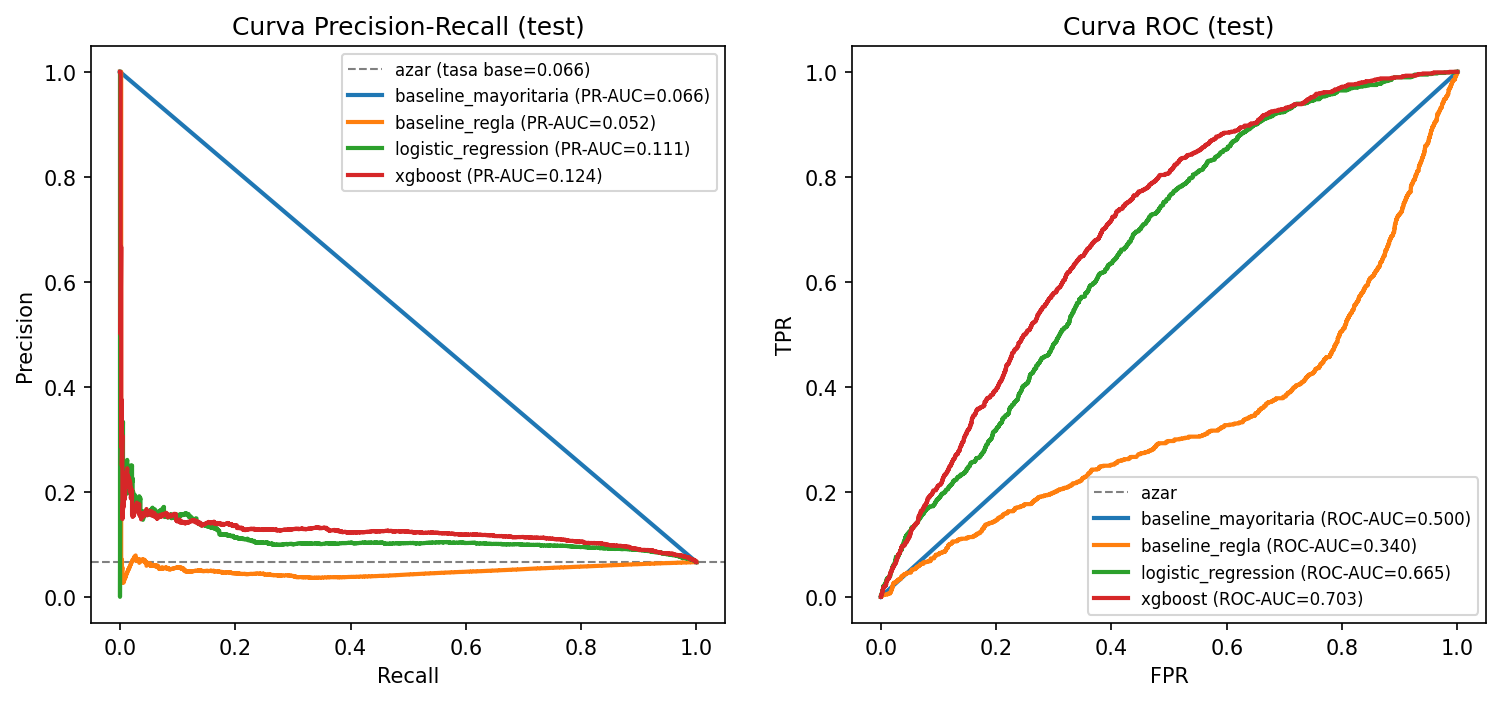

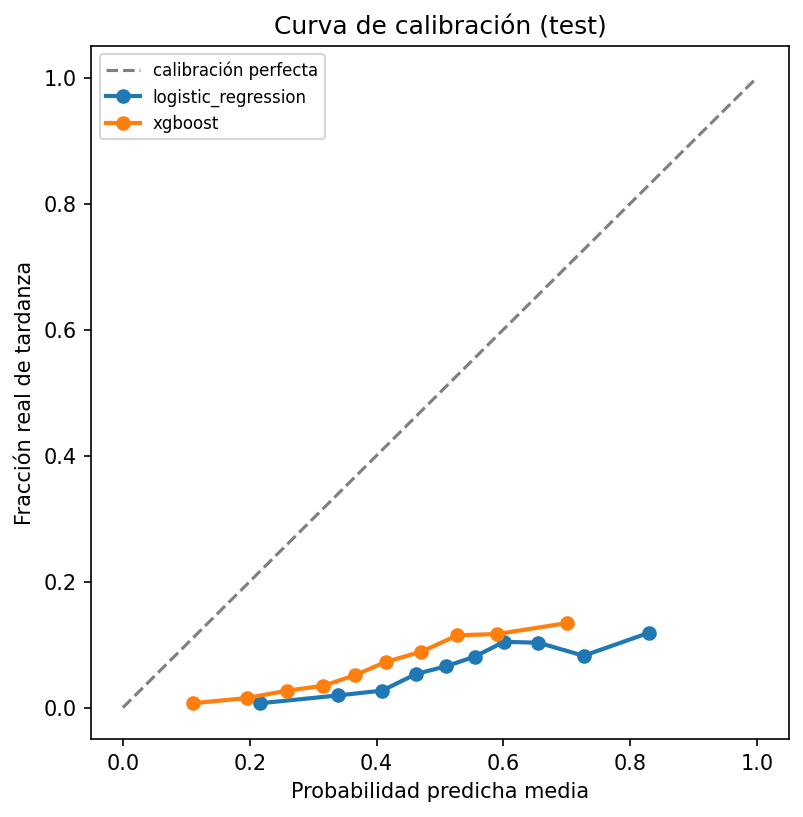

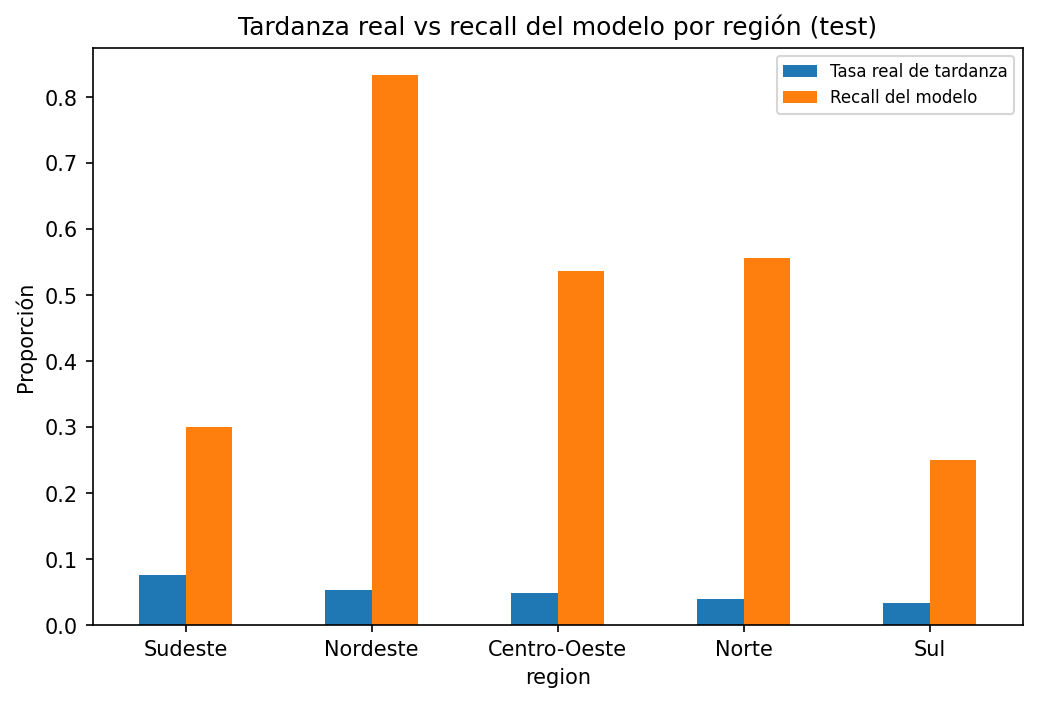

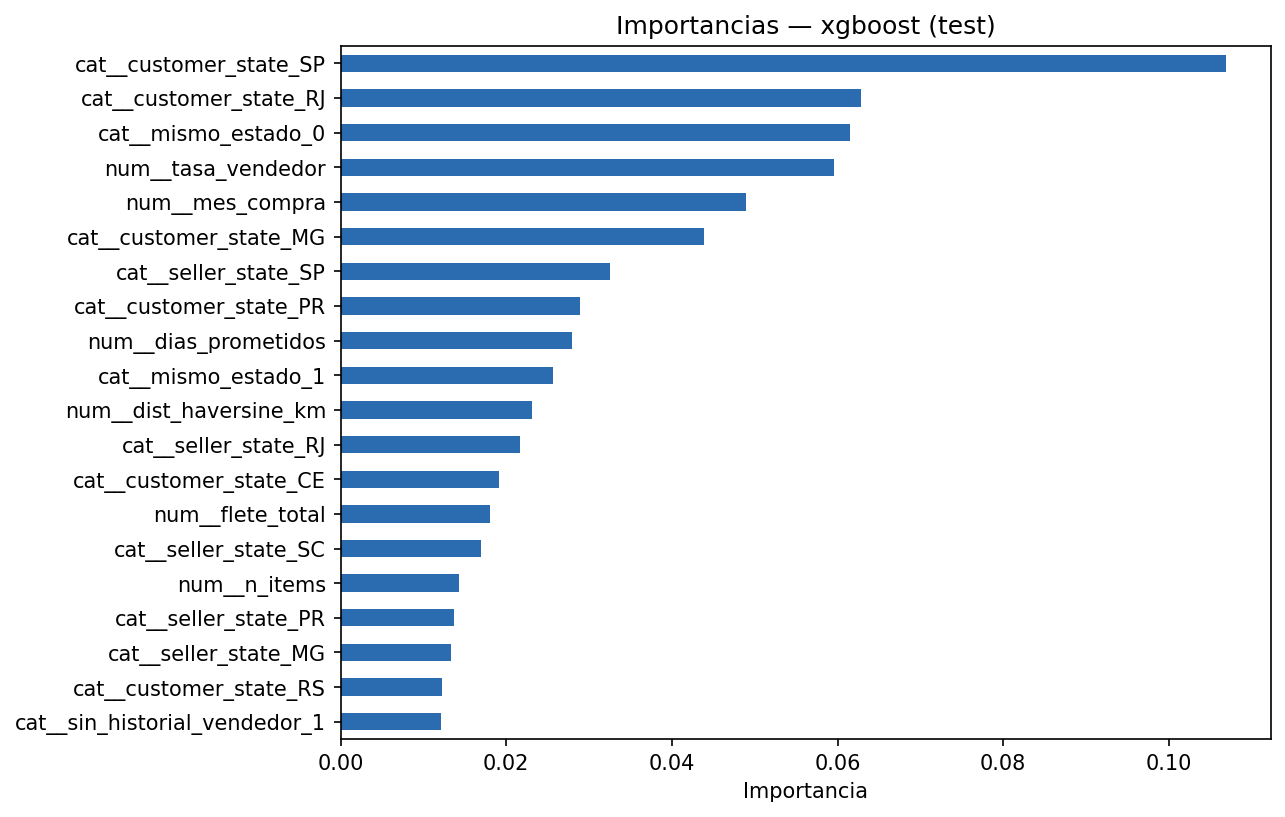

In [6]:
fig = ROOT / 'reports' / 'figures_modelado_etapa4'
for nombre in ['01_curvas_pr_roc.png', '02_calibracion.png',
               '03_error_por_region.png', '04_importancias.png']:
    display(Image(filename=str(fig / nombre)))

## 5. Conclusión

- **Modelo candidato del Sprint 1: XGBoost (`xgb_d4_l2`)** — PR-AUC(test) 0.124 (≈1.9× el azar), ROC-AUC 0.703; supera a la Regresión Logística y a los baselines.
- **Sin fuga** (`tasa_vendedor` 6%, métricas realistas) → resultado honesto y defendible para un MVP.
- Aprende señal de negocio (geografía, cruce de estado, vendedor, estacionalidad) y detecta mejor la tardanza en Nordeste/Norte.
- **Cambio de régimen temporal (R-14):** la tardanza cae de 9.0% (train) a 6.6% (test); se reporta y se difiere el re-ventaneo a la Etapa 6.

Detalle completo en `reports/etapa4_modelado_resultados.md`.